# AP + CHIPR-inspired PES Fitter
### Aguado-Paniagua many-body expansion with CHIPR improvements
- **CHIPR diatomic basis** (sech + csech) replaces AP for ionic/polar systems  
- **REPDAMP** short-range damping on V3 — polynomial forced to zero at compressed bonds  
- **Stratified RMSD** printed per energy stratum  
- **Energy weighting** in 3-body lstsq  
- Systems: H3 (AAA), FH2 (ABB), LiFH (ABC), NaH2 (ABB ionic)

In [1]:
# =============================================================================
# Cell 1: Mount Drive & unzip PES_fit.zip
# =============================================================================
from google.colab import drive
import zipfile, os

drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/PES_fit.zip'   # ← adjust if needed
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall('/content/')

print("Extracted:", os.listdir('/content/PES_fit'))

Mounted at /content/drive
Extracted: ['LiFH', 'Nah2', 'fh2', 'H3_ssmrpt']


In [2]:
# =============================================================================
# Cell 2: Imports
# =============================================================================
import numpy as np
from scipy.optimize import least_squares
import os, warnings
warnings.filterwarnings('ignore')

BFACT = 627.51   # hartree → kcal/mol

In [3]:
# =============================================================================
# Cell 3: Extract NaH2 embedded diatomic data from gfit3c.inp
# (run once after unzip; gfit3c used these 73-pt datasets, not the .dat files)
# =============================================================================
BASE = '/content/PES_fit'

def _extract_nah2_diats(inp_path, out_dir):
    with open(inp_path) as f:
        lines = f.readlines()
    nah = [l for l in lines[2:75]   if len(l.split()) == 2]
    h2  = [l for l in lines[76:149] if len(l.split()) == 2]
    os.makedirs(out_dir, exist_ok=True)
    with open(f'{out_dir}/nah_diat.dat', 'w') as f: f.writelines(nah)
    with open(f'{out_dir}/h2_diat.dat',  'w') as f: f.writelines(h2)
    print(f"Extracted NaH ({len(nah)} pts) and H2 ({len(h2)} pts) → {out_dir}")

_extract_nah2_diats(f'{BASE}/Nah2/gfit3c.inp', f'{BASE}/Nah2')

Extracted NaH (73 pts) and H2 (73 pts) → /content/PES_fit/Nah2


In [5]:
# =============================================================================
# Cell 4: Config — change SYSTEM to switch between H3 / FH2 / LiFH / NaH2
# =============================================================================

SYSTEM = 'LiFH'   # ← 'H3' | 'FH2' | 'LiFH' | 'NaH2'

BASE = '/content/PES_fit'

# diat_basis: 'AP'    → classic Aguado-Paniagua  (rho = R*exp(-beta*R))
#             'CHIPR' → sech + csech basis         (recommended for ionic systems)
# For H3/FH2 AP works fine; for NaH2 CHIPR is strongly preferred.

CONFIGS = {
    'H3': dict(
        indice   = 1,
        diat_AB  = f'{BASE}/H3_ssmrpt/data_h2.out',
        diat_BC  = None, diat_AC = None,
        triat    = f'{BASE}/H3_ssmrpt/data_h3.dat',
        MT_diat  = 8, MT_triat = 9,
        diat_basis = 'AP',
        e0_AB = -0.988498196354, e0_BC = -0.988498196354,
        e0_AC = -0.988498196354, e0_ABC = -1.499487968,
        charged = False, polar = False,
        init_vex_AB = [2.8, 1.2], init_vex_BC = [2.8, 1.2],
        init_vex_AC = [2.8, 1.2], init_vex_triat = [1.0],
        energy_weight_ref_kcal = None,
    ),
    'FH2': dict(
        indice   = 2,
        diat_AB  = f'{BASE}/fh2/fh.dat',    # F-H
        diat_BC  = f'{BASE}/fh2/hh.dat',    # H-H
        diat_AC  = None,
        triat    = f'{BASE}/fh2/fh2.dat',
        MT_diat  = 8, MT_triat = 9,
        diat_basis = 'AP',
        e0_AB = -100.0, e0_BC = -1.0, e0_AC = -100.0, e0_ABC = -100.5,
        charged = False, polar = False,
        init_vex_AB = [0.7, 3.3], init_vex_BC = [1.1, 2.2],
        init_vex_AC = [0.7, 3.3], init_vex_triat = [1.1, 0.8],
        energy_weight_ref_kcal = None,
    ),
    'LiFH': dict(
        indice   = 3,
        diat_AB  = f'{BASE}/LiFH/lif.dat',
        diat_BC  = f'{BASE}/LiFH/hf.dat',
        diat_AC  = f'{BASE}/LiFH/lih.dat',
        triat    = f'{BASE}/LiFH/lifh_unique.dat',
        MT_diat  = 8,
        MT_diat_AB = 5,
        MT_diat_BC = 11,
        MT_diat_AC = 6,
        MT_triat = 9,
        diat_basis = 'CHIPR',
        chipr_AB = dict(
            M      = 5,
            gama   = [3.2667, 4.6867, 0.4211, 0.3404, 0.3845],
            R_ref0 = 2.1361,
            zeta   = 0.4205,
            ZA=3, ZB=9
        ),
        e0_AB    = -107.09133080,
        e0_BC    = -100.19859060,
        e0_AC    = -7.93261861,
        e0_ABC   = -103.16389901,
        charged  = False,
        polar    = True,
        C6_AB    = 13.5,
        energy_cutoff_kcal     = 100,
        energy_weight_ref_kcal = 20.0,
        angular_boost          = True,
        init_vex_AB    = [2.7, 0.9],
        init_vex_BC    = [0.2, 2.6],
        init_vex_AC    = [0.9, 2.3],
        init_vex_triat = [0.55, 0.47, 0.82],


    ),
    'NaH2': dict(
        indice   = 2,
        diat_AB  = f'{BASE}/Nah2/nah_diat.dat',
        diat_BC  = f'{BASE}/Nah2/h2_diat.dat',
        diat_AC  = None,
        triat    = f'{BASE}/Nah2/gfit3c.inp',
        triat_loader = 'inp',
        MT_diat  = 9, MT_triat = 9,
        init_vex_AB    = [1.2, 0.3],
        init_vex_BC    = [1.8, 1.3],
        init_vex_AC    = [1.2, 0.3],
        init_vex_triat = [1.0, 1.0],
        diat_basis = 'CHIPR',
        chipr_AB = dict(
            M      = 4,
            gama   = [8.1246, 1.0321, 0.4465, 0.0985],
            R_ref0 = 8.5160,
            zeta   = 0.0652,
            ZA=11, ZB=1
        ),
        chipr_BC = dict(M=3, gama=[1.8, 1.2, 0.8], R_ref0=1.5, zeta=1.0, ZA=1, ZB=1),
        e0_AB    = -162.1766688,
        e0_BC    = -0.99989664,
        e0_AC    = -162.1766688,
        e0_ABC   = -162.6766175,
        charged  = True, polar = False,
        alpha_neutral = 5.44,
        Q_neutral     = 0.46,
        r_min_bohr    = 1.134,
        energy_weight_ref_kcal = 50.0,
        energy_cutoff_kcal     = None,

    ),
}

cfg = CONFIGS[SYSTEM]
print(f"System: {SYSTEM}  |  indice={cfg['indice']}  |  basis={cfg.get('diat_basis','AP')}")

System: LiFH  |  indice=3  |  basis=CHIPR


In [11]:
# =============================================================================
# Cell 5: Data loaders
# =============================================================================

def load_diatomic(path, e0=0.0):
    rows = []
    with open(path) as f:
        for line in f:
            parts = line.split()
            if len(parts) < 2: continue
            try: rows.append((float(parts[0]), float(parts[1]) - e0))
            except ValueError: continue
    data = np.array(rows)
    print(f"  Loaded {len(data)} diatomic points from {os.path.basename(path)}")
    return data[:, 0], data[:, 1]

def load_triatomic(path):
    """gfit3c col order: R12, R23, R13, E  →  returns R12, R13, R23, E"""
    data = np.loadtxt(path)
    print(f"  Loaded {data.shape[0]} triatomic points from {os.path.basename(path)}")
    return data[:,0], data[:,2], data[:,1], data[:,3]

def load_triatomic_from_inp(inp_path, skip=150):
    """Load triatomic block embedded in gfit3c.inp (NaH2)."""
    rows = []
    with open(inp_path) as f:
        for i, line in enumerate(f):
            if i < skip: continue
            p = line.split()
            if len(p) == 4:
                try: rows.append([float(x) for x in p])
                except ValueError: break
    data = np.array(rows)
    print(f"  Loaded {len(data)} triatomic points from inp file")
    return data[:,0], data[:,2], data[:,1], data[:,3]  # R12,R13,R23,E

In [12]:
# =============================================================================
# Cell 6: Diatomic basis functions & fitting
# =============================================================================
# Two basis choices:
#   AP    — classic Aguado-Paniagua: V = c0*exp(-b2*R)/R + sum c_i*(R*exp(-b1*R))^i
#   CHIPR — sech + csech basis:      V = (ZA*ZB/R) * sum C_i * Y^i
#           where Y = sum_j c_j * phi_j(R)
#           phi_j = sech(gama_j*(R - R_ref_j))          [j < M]
#           phi_M = (tanh(R/5)/R)^6 * sech(gama_M*(R-R_ref_M))  [long-range]
#           R_ref_j = zeta * R_ref0^(j-1)              [distributed origins]
# =============================================================================

# ── AP basis ─────────────────────────────────────────────────────────────────

def build_ap_basis(R, beta1, beta2, M):
    N = len(R); X = np.zeros((N, M))
    X[:, 0] = np.exp(-beta2 * R) / R
    rho = R * np.exp(-beta1 * R); aux = np.ones(N)
    for i in range(1, M):
        aux = aux * rho; X[:, i] = aux
    return X

def eval_ap(R, beta1, beta2, c):
    return build_ap_basis(R, beta1, beta2, len(c)) @ c

def fit_ap(R, E, M, init_vex):
    """Grid scan ±0.5 (3 pts) then TRF refinement — mirrors gfit3c MINIM."""
    x0 = np.array(init_vex, dtype=float)
    best_rms = 1e10; best_b1, best_b2 = x0[0], x0[1]
    for dx1 in [-0.5, 0.0, 0.5]:
        for dx2 in [-0.5, 0.0, 0.5]:
            b1, b2 = x0[0]+dx1, x0[1]+dx2
            if b1 <= 0 or b2 <= 0: continue
            X = build_ap_basis(R, b1, b2, M); c,_,_,_ = np.linalg.lstsq(X, E, rcond=None)
            r = np.sqrt(np.mean((X@c - E)**2))
            if r < best_rms: best_rms=r; best_b1,best_b2 = b1,b2
    def res(v):
        X = build_ap_basis(R, abs(v[0]), abs(v[1]), M); c,_,_,_ = np.linalg.lstsq(X, E, rcond=None)
        return X@c - E
    r = least_squares(res, [best_b1, best_b2], method='trf',
                      bounds=([0.05,0.05],[6.0,6.0]), ftol=1e-14, xtol=1e-14,
                      gtol=1e-14, max_nfev=50000)
    b1, b2 = abs(r.x)
    X = build_ap_basis(R, b1, b2, M); c,_,_,_ = np.linalg.lstsq(X, E, rcond=None)
    resid = X@c - E
    rms = np.sqrt(np.mean(resid**2)); emax = np.max(np.abs(resid))*BFACT
    print(f"    beta1={b1:.6f}  beta2={b2:.6f}  RMS={rms:.6f} au = {rms*BFACT:.4f} kcal/mol  Emax={emax:.4f} kcal/mol")
    return b1, b2, c, rms, emax

# ── CHIPR basis ───────────────────────────────────────────────────────────────

def _sech(x):
    return 1.0 / np.cosh(x)

def build_chipr_basis(R, chipr_params):
    """
    Build CHIPR design matrix X such that V(R) = (ZA*ZB/R) * (X @ c_lin)^L
    Here we use L=1 (linear in Y) for simplicity matching CHIPR paper eq.
    Returns X (N×M) where Y_contracted = X @ c_lin.
    """
    M      = chipr_params['M']
    gama   = np.array(chipr_params['gama'])
    R_ref0 = chipr_params['R_ref0']
    zeta   = chipr_params['zeta']
    ZA, ZB = chipr_params['ZA'], chipr_params['ZB']
    N = len(R)
    X = np.zeros((N, M))
    for j in range(M-1):           # sech basis functions
        R_ref_j = zeta * R_ref0**j
        rho = R - R_ref_j
        X[:, j] = _sech(gama[j] * rho)
    # Last: csech = (tanh(R/5)/R)^6 * sech(gamma*(R - R_ref_M))
    R_ref_M = zeta * R_ref0**(M-1)
    rho_M = R - R_ref_M
    fac_lr = (np.tanh(R / 5.0) / R)**6
    X[:, M-1] = fac_lr * _sech(gama[M-1] * rho_M)
    # Multiply by ZA*ZB/R prefactor (enforces physical repulsion at R→0)
    prefac = (ZA * ZB) / R
    return X * prefac[:, None]

def eval_chipr(R, chipr_params, c):
    return build_chipr_basis(R, chipr_params) @ c

def fit_chipr(R, E, chipr_params):
    """Fit CHIPR basis: nonlinear params fixed, linear coeffs by lstsq."""
    X = build_chipr_basis(R, chipr_params)
    c,_,_,_ = np.linalg.lstsq(X, E, rcond=None)
    resid = X@c - E
    rms = np.sqrt(np.mean(resid**2)); emax = np.max(np.abs(resid))*BFACT
    print(f"    CHIPR M={chipr_params['M']}  RMS={rms:.6f} au = {rms*BFACT:.4f} kcal/mol  Emax={emax:.4f} kcal/mol")
    return c, rms, emax

# ── Unified diatomic interface ─────────────────────────────────────────────

def fit_diatom(R, E, M, init_vex, basis='AP', chipr_params=None):
    if basis == 'CHIPR' and chipr_params is not None:
        c, rms, emax = fit_chipr(R, E, chipr_params)
        return None, None, c, rms, emax   # b1,b2 = None for CHIPR
    else:
        return fit_ap(R, E, M, init_vex)

def eval_diatom(R, b1, b2, c, basis='AP', chipr_params=None):
    if basis == 'CHIPR' and chipr_params is not None:
        return eval_chipr(R, chipr_params, c)
    else:
        return eval_ap(R, b1, b2, c)
def optimize_chipr_params(R, E, M=4, n_trials=20):
    """
    Optimize CHIPR nonlinear parameters (gama, R_ref0, zeta) by minimizing
    diatomic RMS. Uses random multi-start to avoid local minima.
    Returns best chipr_params dict.
    """
    from scipy.optimize import minimize
    ZA, ZB = 11, 1   # Na, H

    def rms_given_params(p):
        gama  = np.abs(p[:M])
        R_ref0 = np.abs(p[M])
        zeta   = np.abs(p[M+1])
        params = dict(M=M, gama=gama, R_ref0=R_ref0, zeta=zeta, ZA=ZA, ZB=ZB)
        try:
            X = build_chipr_basis(R, params)
            c,_,_,_ = np.linalg.lstsq(X, E, rcond=None)
            return np.sqrt(np.mean((X@c - E)**2))
        except:
            return 1e10

    best_rms = 1e10; best_p = None
    rng = np.random.default_rng(0)
    for _ in range(n_trials):
        gama_init  = rng.uniform(0.3, 2.0, M)
        R_ref0_init = rng.uniform(1.0, 5.0)
        zeta_init   = rng.uniform(0.5, 2.0)
        p0 = np.concatenate([gama_init, [R_ref0_init, zeta_init]])
        res = minimize(rms_given_params, p0, method='Nelder-Mead',
                       options={'maxiter':5000, 'xatol':1e-6, 'fatol':1e-8})
        if res.fun < best_rms:
            best_rms = res.fun; best_p = res.x

    gama   = np.abs(best_p[:M])
    R_ref0 = np.abs(best_p[M])
    zeta   = np.abs(best_p[M+1])
    print(f"Optimized CHIPR: gama={np.round(gama,4)} R_ref0={R_ref0:.4f} zeta={zeta:.4f}")
    print(f"  RMS = {best_rms:.6f} au = {best_rms*BFACT:.4f} kcal/mol")
    return dict(M=M, gama=list(gama), R_ref0=float(R_ref0), zeta=float(zeta), ZA=ZA, ZB=ZB)



In [13]:
# =============================================================================
# Cell 7: Long-range corrections
# =============================================================================

def vlr_ion_induced_dipole(R, alpha):
    """V = -alpha/(2R^4) with Tang-Toennies damping (b=2, n=4)."""
    bR = 2.0 * R
    damp = 1.0 - np.exp(-bR) * (1 + bR + bR**2/2 + bR**3/6 + bR**4/24)
    return -alpha * damp / (2.0 * R**4)

def vlr_dipole_induced_dipole(R, C6):
    return -C6 / R**6

def subtract_lr_charged(R12, R13, R23, E, cfg):
    alpha = cfg['alpha_neutral']
    R12_s = np.maximum(R12, 2.0); R13_s = np.maximum(R13, 2.0)
    V_lr = vlr_ion_induced_dipole(R12_s, alpha) + vlr_ion_induced_dipole(R13_s, alpha)
    print(f"  Long-range (ion-induced dipole) subtracted: mean |V_lr| = {np.mean(np.abs(V_lr)):.4e} au")
    return E - V_lr

def subtract_lr_polar(R12, R13, R23, E, cfg):
    """
    LiF(A-B) + H(C): dipole-induced dipole V = -mu_LiF^2 * alpha_H / (2 * R_LiH^6)
    But ONLY at large R — use a smooth switch that turns off below 5 bohr.
    R13 = R_LiH = distance from Li (A) to H (C)
    """
    C6   = cfg.get('C6_AB', 0.0)
    if C6 == 0.0:
        return E

    # Switching function: smoothly zero below R_switch, full above
    R_switch = 5.0   # bohr
    alpha_sw = 2.0
    R_LiH    = R13
    switch   = 1.0 / (1.0 + np.exp(-alpha_sw * (R_LiH - R_switch)))

    V_lr = -C6 * switch / R_LiH**6
    print(f"  Long-range (dipole, switched): mean |V_lr| = {np.mean(np.abs(V_lr)):.4e} au")
    return E - V_lr

In [14]:
# =============================================================================
# Cell 8: 3-Body basis — exact gfit3c index tables + CHIPR REPDAMP
# =============================================================================

IPA31 = [
    (0,1,1,3),(1,1,1,1),(2,1,0,6),(2,1,1,3),(0,2,2,3),
    (3,1,0,6),(1,2,2,3),(3,1,1,3),(3,2,0,6),(4,1,0,6),
    (2,2,2,1),(3,2,1,6),(0,3,3,3),(4,1,1,3),(4,2,0,6),
    (5,1,0,6),(3,2,2,3),(1,3,3,3),(4,2,1,6),(4,3,0,6),
    (5,1,1,3),(5,2,0,6),(6,1,0,6),(2,3,3,3),(4,2,2,3),
    (4,3,1,6),(0,4,4,3),(5,2,1,6),(5,3,0,6),(6,1,1,3),
    (6,2,0,6),(7,1,0,6),(3,3,3,1),(4,3,2,6),(1,4,4,3),
    (5,2,2,3),(5,3,1,6),(5,4,0,6),(6,2,1,6),(6,3,0,6),
    (7,1,1,3),(7,2,0,6),(8,1,0,6),(4,3,3,3),(2,4,4,3),
    (5,3,2,6),(5,4,1,6),(0,5,5,3),(6,2,2,3),(6,3,1,6),
    (6,4,0,6),(7,2,1,6),(7,3,0,6),(8,1,1,3),(8,2,0,6),
    (9,1,0,6),
]
NFAS31 = [0, 1, 3, 6, 10, 16, 23, 32, 43, 56]

IPA32 = [
    (1,1,0,2),(1,0,1,1),(1,1,1,1),(2,1,0,2),(2,0,1,2),(0,2,1,2),(2,1,1,2),(1,2,1,1),(2,2,0,2),(2,0,2,1),
    (3,1,0,2),(3,0,1,2),(0,3,1,2),(2,2,1,2),(2,1,2,1),(3,1,1,2),(1,3,1,1),(3,2,0,2),(3,0,2,2),(0,3,2,2),
    (4,1,0,2),(4,0,1,2),(0,4,1,2),(2,2,2,1),(3,2,1,2),(3,1,2,2),(1,3,2,2),(3,3,0,2),(3,0,3,1),(4,1,1,2),
    (1,4,1,1),(4,2,0,2),(4,0,2,2),(0,4,2,2),(5,1,0,2),(5,0,1,2),(0,5,1,2),(3,2,2,2),(2,3,2,1),(3,3,1,2),
    (3,1,3,1),(4,2,1,2),(4,1,2,2),(1,4,2,2),(4,3,0,2),(4,0,3,2),(0,4,3,2),(5,1,1,2),(1,5,1,1),(5,2,0,2),
    (5,0,2,2),(0,5,2,2),(6,1,0,2),(6,0,1,2),(0,6,1,2),(3,3,2,2),(3,2,3,1),(4,2,2,2),(2,4,2,1),(4,3,1,2),
    (4,1,3,2),(1,4,3,2),(4,4,0,2),(4,0,4,1),(5,2,1,2),(5,1,2,2),(1,5,2,2),(5,3,0,2),(5,0,3,2),(0,5,3,2),
    (6,1,1,2),(1,6,1,1),(6,2,0,2),(6,0,2,2),(0,6,2,2),(7,1,0,2),(7,0,1,2),(0,7,1,2),(3,3,3,1),(4,3,2,2),
    (4,2,3,2),(2,4,3,2),(4,4,1,2),(4,1,4,1),(5,2,2,2),(2,5,2,1),(5,3,1,2),(5,1,3,2),(1,5,3,2),(5,4,0,2),
    (5,0,4,2),(0,5,4,2),(6,2,1,2),(6,1,2,2),(1,6,2,2),(6,3,0,2),(6,0,3,2),(0,6,3,2),(7,1,1,2),(1,7,1,1),
    (7,2,0,2),(7,0,2,2),(0,7,2,2),(8,1,0,2),(8,0,1,2),(0,8,1,2),(4,3,3,2),(3,4,3,1),(4,4,2,2),(4,2,4,1),
    (5,3,2,2),(5,2,3,2),(2,5,3,2),(5,4,1,2),(5,1,4,2),(1,5,4,2),(5,5,0,2),(5,0,5,1),(6,2,2,2),(2,6,2,1),
    (6,3,1,2),(6,1,3,2),(1,6,3,2),(6,4,0,2),(6,0,4,2),(0,6,4,2),(7,2,1,2),(7,1,2,2),(1,7,2,2),(7,3,0,2),
    (7,0,3,2),(0,7,3,2),(8,1,1,2),(1,8,1,1),(8,2,0,2),(8,0,2,2),(0,8,2,2),(9,1,0,2),(9,0,1,2),(0,9,1,2),
]
NFAS33 = [0, 3, 10, 22, 40, 65, 98, 140, 192, 255, 285, 363]
#                                                   ↑ MT=10  ↑ MT=11

def _gen_ipa33():
    entries = []
    for deg in range(1, 12):   # ← was range(1, 10), extend to 12 to cover MT=11
        for i in range(deg+1):
            for j in range(deg-i+1):
                entries.append((i, j, deg-i-j))
    return entries

IPA33 = _gen_ipa33()
NFAS33 = [0, 3, 10, 22, 40, 65, 98, 140, 192, 255, 285, 363]

# Quick sanity check
assert len(IPA33) >= 363, f"IPA33 too short: {len(IPA33)}"
print(f"IPA33: {len(IPA33)} monomials generated, NFAS33 max = {NFAS33[-1]}")

def get_3body_monomials(MT, indice):
    if indice == 1:  return IPA31[:NFAS31[MT]]
    elif indice == 2: return IPA32[:NFAS32[MT]]
    else:            return IPA33[:NFAS33[MT]]

def repdamp(R12, R13, R23, R0=0.5, kappa=100.0, xi=10.0):
    """
    CHIPR REPDAMP: forces V3→0 whenever any bond is very short (< R0 bohr).
    Prevents polynomial from being wasted fitting the repulsive wall.
    REPDAMP = product_i [ 0.5*(1+tanh(kappa*(Ri-R0))) ]^xi
    """
    h = lambda R: 0.5 * (1.0 + np.tanh(kappa * (R - R0)))
    return (h(R12) * h(R13) * h(R23))**xi

def build_3body_basis(R12, R13, R23, betas, monomials, indice, use_repdamp=True):
    """
    Build 3-body design matrix.
    use_repdamp=True multiplies each row by CHIPR REPDAMP factor.
    """
    if indice == 1:
        b12 = b13 = b23 = betas[0]
    elif indice == 2:
        b12 = b13 = betas[0]; b23 = betas[1]
    else:
        b12, b13, b23 = betas[0], betas[1], betas[2]

    N = len(R12)
    max_deg = max(max(m[:3]) for m in monomials) + 1
    rho12 = R12 * np.exp(-betas[0] * R12)
    rho13 = R13 * np.exp(-betas[1] * R13)
    rho23 = R23 * np.exp(-betas[2] * R23)
    f12 = np.ones((N,max_deg+1)); f13 = np.ones((N,max_deg+1)); f23 = np.ones((N,max_deg+1))
    for k in range(1, max_deg+1):
        f12[:,k]=f12[:,k-1]*rho12; f13[:,k]=f13[:,k-1]*rho13; f23[:,k]=f23[:,k-1]*rho23

    X = np.zeros((N, len(monomials)))

    if indice == 1:
        for col,(i,j,k,sym) in enumerate(monomials):
            if sym==1: X[:,col]=f12[:,i]*f13[:,j]*f23[:,k]
            elif sym==3: X[:,col]=(f12[:,i]*f13[:,j]*f23[:,k]+f12[:,j]*f13[:,i]*f23[:,k]
                                   +f12[:,j]*f13[:,k]*f23[:,i])
            elif sym==6: X[:,col]=(f12[:,i]*f13[:,j]*f23[:,k]+f12[:,i]*f13[:,k]*f23[:,j]
                                   +f12[:,j]*f13[:,i]*f23[:,k]+f12[:,j]*f13[:,k]*f23[:,i]
                                   +f12[:,k]*f13[:,i]*f23[:,j]+f12[:,k]*f13[:,j]*f23[:,i])
    elif indice == 2:
        for col,(i1,i2,i3,sym) in enumerate(monomials):
            if sym==1: X[:,col]=f12[:,i1]*f13[:,i3]*f23[:,i2]
            elif sym==2: X[:,col]=(f12[:,i1]*f13[:,i3]+f12[:,i3]*f13[:,i1])*f23[:,i2]
    else:
        for col,(i,j,k) in enumerate(monomials):
            X[:,col]=f12[:,i]*f13[:,j]*f23[:,k]

    # CHIPR REPDAMP — multiply rows by damping factor
    if use_repdamp:
        damp = repdamp(R12, R13, R23)
        X = X * damp[:, None]

    return X

IPA33: 363 monomials generated, NFAS33 max = 363


In [15]:
# =============================================================================
# Cell 9: 3-Body fitting with subset scan + energy weighting
# =============================================================================

def fit_3body(R12, R13, R23, E_resid, betas_init, monomials, indice,
              weights=None, use_repdamp=True):
    """
    Phase 1: grid scan on ≤8000-pt subset (mirrors gfit3c MINIM).
    Phase 2: LM refinement on subset.
    Phase 3: final lstsq on full dataset.
    weights: per-point array; if None, uniform weighting.
    use_repdamp: apply CHIPR short-range damping to design matrix.
    """
    if weights is None:
        weights = np.ones(len(R12))

    N = len(R12)
    MAX_SCAN = 8000
    if N > MAX_SCAN:
        idx = np.random.default_rng(42).choice(N, MAX_SCAN, replace=False)
        R12s,R13s,R23s,Ers,ws = R12[idx],R13[idx],R23[idx],E_resid[idx],weights[idx]
    else:
        R12s,R13s,R23s,Ers,ws = R12,R13,R23,E_resid,weights

    def rms_scan(betas):
        betas = np.abs(betas)
        X = build_3body_basis(R12s,R13s,R23s,betas,monomials,indice,use_repdamp)
        Xw=X*ws[:,None]; Ew=Ers*ws
        c,_,_,_=np.linalg.lstsq(Xw,Ew,rcond=None)
        return np.sqrt(np.mean((X@c-Ers)**2))

    def residuals_scan(b):
        betas = np.abs(b)
        X = build_3body_basis(R12s,R13s,R23s,betas,monomials,indice,use_repdamp)
        Xw=X*ws[:,None]; Ew=Ers*ws
        c,_,_,_=np.linalg.lstsq(Xw,Ew,rcond=None)
        return (X@c-Ers)*ws

    x0 = np.array(betas_init, dtype=float)
    n_beta = len(x0)
    best_rms = 1e10; best_x = x0.copy()

    if n_beta == 1:
        for dx in np.arange(-0.6, 0.61, 0.3):
            xc = np.array([x0[0]+dx])
            if xc[0] <= 0: continue
            r = rms_scan(xc)
            if r < best_rms: best_rms=r; best_x=xc.copy()
    elif n_beta == 2:
        for dx1 in [-0.5,0.0,0.5]:
            for dx2 in [-0.5,0.0,0.5]:
                xc = np.array([x0[0]+dx1, x0[1]+dx2])
                if any(v<=0 for v in xc): continue
                r = rms_scan(xc)
                if r < best_rms: best_rms=r; best_x=xc.copy()
    else:
        for dx1 in [-0.5,0.0,0.5]:
            for dx2 in [-0.5,0.0,0.5]:
                for dx3 in [-0.5,0.0,0.5]:
                    xc = np.array([x0[0]+dx1,x0[1]+dx2,x0[2]+dx3])
                    if any(v<=0 for v in xc): continue
                    r = rms_scan(xc)
                    if r < best_rms: best_rms=r; best_x=xc.copy()

    result = least_squares(residuals_scan, best_x, method='lm',
                           ftol=1e-12, xtol=1e-12, gtol=1e-12, max_nfev=20000)
    betas = np.abs(result.x)

    # Final lstsq on FULL dataset with weighting
    X = build_3body_basis(R12,R13,R23,betas,monomials,indice,use_repdamp)
    Xw=X*weights[:,None]; Ew=E_resid*weights
    c,_,_,_=np.linalg.lstsq(Xw,Ew,rcond=None)
    resid = X@c - E_resid
    rms  = np.sqrt(np.mean(resid**2))
    emax = np.max(np.abs(resid))*BFACT
    print(f"    betas={betas}  RMS={rms:.6f} au = {rms*BFACT:.4f} kcal/mol  Emax={emax:.4f} kcal/mol")
    print(f"    n_terms={len(monomials)}")
    return betas, c, rms, emax

def _3body_residuals(R12,R13,R23,E_resid,betas_raw,monomials,indice,use_repdamp=True):
    betas=np.abs(betas_raw)
    X=build_3body_basis(R12,R13,R23,betas,monomials,indice,use_repdamp)
    c,_,_,_=np.linalg.lstsq(X,E_resid,rcond=None)
    return X@c-E_resid

In [16]:
# =============================================================================
# Cell 10: Stratified RMSD — inspired by CHIPR STRAT_RMSD subroutine
# Prints RMS per energy stratum so you can see where errors come from.
# =============================================================================

def print_stratified_rmsd(E_ab, E_fit, system_name, n_strat=8):
    """
    Divide energy range into n_strat strata and print RMS + N_pts per stratum.
    E_ab, E_fit in hartree. Strata defined relative to minimum energy.
    """
    err_kcal = (E_fit - E_ab) * BFACT
    E_rel    = (E_ab  - E_ab.min()) * BFACT   # kcal above minimum

    # Define strata boundaries
    boundaries = [0, 5, 10, 20, 50, 100, 200, 500, 1e9]
    labels      = ['0–5','5–10','10–20','20–50','50–100','100–200','200–500','>500']

    print(f"\n{'─'*60}")
    print(f"  Stratified RMSD — {system_name}")
    print(f"  {'Stratum (kcal)':>18}  {'N pts':>6}  {'RMS (kcal/mol)':>15}  {'Emax (kcal/mol)':>16}")
    print(f"{'─'*60}")
    for lo, hi, lab in zip(boundaries[:-1], boundaries[1:], labels):
        m = (E_rel >= lo) & (E_rel < hi)
        if m.sum() == 0: continue
        rms_s  = np.sqrt(np.mean(err_kcal[m]**2))
        emax_s = np.max(np.abs(err_kcal[m]))
        print(f"  {lab:>18}  {m.sum():>6}  {rms_s:>15.4f}  {emax_s:>16.4f}")
    print(f"{'─'*60}")
    overall_rms = np.sqrt(np.mean(err_kcal**2))
    print(f"  {'OVERALL':>18}  {len(err_kcal):>6}  {overall_rms:>15.4f}  {np.max(np.abs(err_kcal)):>16.4f}")
    print(f"{'─'*60}\n")

In [17]:
# =============================================================================
# Cell 11: Full PES evaluator
# =============================================================================

def eval_pes(R12, R13, R23, res, cfg):
    """Evaluate fitted PES at given geometries (bohr). Returns energy in hartree."""
    R12 = np.atleast_1d(np.asarray(R12, float))
    R13 = np.atleast_1d(np.asarray(R13, float))
    R23 = np.atleast_1d(np.asarray(R23, float))
    basis  = cfg.get('diat_basis', 'AP')
    indice = res['indice']

    # ── 2-body terms ─────────────────────────────────────────────────────────
    V2_AB = eval_diatom(R12, res['b1_AB'], res['b2_AB'], res['c_AB'],
                        basis=basis, chipr_params=cfg.get('chipr_AB'))

    if indice == 2:
        # ABB: AC bond identical to AB — reuse AB params and basis
        V2_AC = eval_diatom(R13, res['b1_AB'], res['b2_AB'], res['c_AB'],
                            basis=basis, chipr_params=cfg.get('chipr_AB'))
    else:
        # ABC: distinct AC bond, always AP
        V2_AC = eval_diatom(R13, res['b1_AC'], res['b2_AC'], res['c_AC'],
                            basis='AP', chipr_params=None)

    V2_BC = eval_diatom(R23, res['b1_BC'], res['b2_BC'], res['c_BC'],
                        basis='AP', chipr_params=cfg.get('chipr_BC'))

    # ── 3-body term ───────────────────────────────────────────────────────────
    X3 = build_3body_basis(R12, R13, R23, res['betas_3'],
                           res['monomials'], indice,
                           use_repdamp=res.get('use_repdamp', True))
    V3 = X3 @ res['c_3']

    # ── Long-range corrections (same switched form as subtract_lr_*) ─────────
    V_lr = np.zeros_like(R12)

    if cfg.get('charged', False):
        alpha = cfg['alpha_neutral']
        V_lr += vlr_ion_induced_dipole(R12, alpha) + vlr_ion_induced_dipole(R13, alpha)

    if cfg.get('polar', False):
        C6 = cfg.get('C6_AB', 0.0)
        if C6 != 0.0:
            R_switch = 5.0; alpha_sw = 2.0
            switch = 1.0 / (1.0 + np.exp(-alpha_sw * (R13 - R_switch)))
            V_lr += -C6 * switch / R13**6

    # ── Total ─────────────────────────────────────────────────────────────────
    return V2_AB + V2_AC + V2_BC + V3 + cfg['e0_ABC'] + V_lr

In [18]:
# =============================================================================
# Cell 12: Main fitting pipeline
# =============================================================================

def run_fit(SYSTEM, cfg):
    print(f"\n{'='*60}")
    print(f"  System: {SYSTEM}  (indice={cfg['indice']})  basis={cfg.get('diat_basis','AP')}")
    print(f"{'='*60}")

    indice  = cfg['indice']
    MT_t    = cfg['MT_triat']
    basis   = cfg.get('diat_basis', 'AP')

    MT_d_AB = cfg.get('MT_diat_AB', cfg['MT_diat'])
    MT_d_BC = cfg.get('MT_diat_BC', cfg['MT_diat'])
    MT_d_AC = cfg.get('MT_diat_AC', cfg['MT_diat'])

    # ── 2-body fits ──────────────────────────────────────────────────────────
    print("\n--- Diatomic AB ---")
    R_AB, E_AB = load_diatomic(cfg['diat_AB'], e0=cfg['e0_AB'])
    b1_AB, b2_AB, c_AB, _, _ = fit_diatom(R_AB, E_AB, MT_d_AB, cfg['init_vex_AB'],
                                           basis=basis, chipr_params=cfg.get('chipr_AB'))

    if indice >= 2 and cfg.get('diat_BC'):
        print("\n--- Diatomic BC ---")
        R_BC, E_BC = load_diatomic(cfg['diat_BC'], e0=cfg['e0_BC'])
        b1_BC, b2_BC, c_BC, _, _ = fit_diatom(R_BC, E_BC, MT_d_BC, cfg['init_vex_BC'],
                                               basis='AP', chipr_params=cfg.get('chipr_BC'))
    else:
        b1_BC, b2_BC, c_BC = b1_AB, b2_AB, c_AB.copy()

    if indice == 3 and cfg.get('diat_AC'):
        print("\n--- Diatomic AC ---")
        R_AC, E_AC = load_diatomic(cfg['diat_AC'], e0=cfg['e0_AC'])
        b1_AC, b2_AC, c_AC, _, _ = fit_diatom(R_AC, E_AC, MT_d_AC, cfg['init_vex_AC'],
                                               basis='AP')
    else:
        # For ABB: AC uses same diatomic as AB (b1/b2 may be None for CHIPR — that's fine)
        b1_AC, b2_AC, c_AC = b1_AB, b2_AB, c_AB.copy()

    # ── Load triatomic data ───────────────────────────────────────────────────
    print("\n--- Triatomic data ---")
    if cfg.get('triat_loader') == 'inp':
        R12, R13, R23, E_total = load_triatomic_from_inp(cfg['triat'])
    else:
        R12, R13, R23, E_total = load_triatomic(cfg['triat'])

    r_min = cfg.get('r_min_bohr', 0.0)
    if r_min > 0:
        mask = (R12>=r_min)&(R13>=r_min)&(R23>=r_min)
        R12,R13,R23,E_total = R12[mask],R13[mask],R23[mask],E_total[mask]
        print(f"  After R_min={r_min} bohr filter: {mask.sum()} / {len(mask)} points kept")

    cutoff = cfg.get('energy_cutoff_kcal')
    if cutoff is not None:
        mask = (E_total - E_total.min())*BFACT <= cutoff
        R12,R13,R23,E_total = R12[mask],R13[mask],R23[mask],E_total[mask]
        print(f"  After {cutoff} kcal/mol cutoff: {mask.sum()} points kept")

    # ── Subtract long-range ───────────────────────────────────────────────────
    E_work = E_total.copy()
    if cfg.get('charged'): E_work = subtract_lr_charged(R12,R13,R23,E_work,cfg)
    if cfg.get('polar'):   E_work = subtract_lr_polar(R12,R13,R23,E_work,cfg)

    # ── Subtract 2-body + reference ──────────────────────────────────────────
    # V2_AB: always uses AB basis (may be CHIPR)
    V2_AB = eval_diatom(R12, b1_AB, b2_AB, c_AB,
                        basis=basis, chipr_params=cfg.get('chipr_AB'))

    # V2_AC: for ABB (indice=2) the AC bond is identical to AB → reuse AB params/basis
    #        for ABC (indice=3) it is a distinct bond → always AP
    if indice == 2:
        V2_AC = eval_diatom(R13, b1_AB, b2_AB, c_AB,
                            basis=basis, chipr_params=cfg.get('chipr_AB'))
    else:
        V2_AC = eval_diatom(R13, b1_AC, b2_AC, c_AC,
                            basis='AP', chipr_params=None)

    # V2_BC: always AP (HH bond for FH2/NaH2, FH bond for LiFH)
    V2_BC = eval_diatom(R23, b1_BC, b2_BC, c_BC,
                        basis='AP', chipr_params=cfg.get('chipr_BC'))

    E_resid = E_work - (V2_AB + V2_AC + V2_BC) - cfg['e0_ABC']

    resid_rms = np.sqrt(np.mean(E_resid**2))
    print(f"\n  3-body residual RMS before fit: {resid_rms:.6f} au = {resid_rms*BFACT:.4f} kcal/mol")

    # ── 3-body fit ────────────────────────────────────────────────────────────
    print("\n--- 3-body fit ---")
    monomials = get_3body_monomials(MT_t, indice)
    print(f"  Polynomial degree <= {MT_t-1}, n_terms = {len(monomials)}")

    use_repdamp = True

    E_wref = cfg.get('energy_weight_ref_kcal')
    if E_wref is not None:
        E_rel_kcal = (E_total - E_total.min()) * BFACT
        # Base cubic energy weight
        fit_weights = (E_wref / (E_wref + np.clip(E_rel_kcal, 0, None)))**3

        # Extra angular coverage weight for LiFH: boost sparsely-sampled angles in the well
        if cfg.get('angular_boost', False):
            cos_th = (R12**2 + R23**2 - R13**2) / (2*R12*R23)
            ang = np.degrees(np.arccos(np.clip(cos_th, -1, 1)))
            # Count pts in well per angle, boost angles with few points
            ang_round = np.round(ang, 0)
            E_rel_kcal_full = E_rel_kcal
            well_mask = E_rel_kcal_full <= 5
            ang_boost = np.ones(len(R12))
            for a in np.unique(ang_round):
                m = ang_round == a
                n_well = (m & well_mask).sum()
                if n_well > 0 and n_well < 20:   # sparse angle in well
                    ang_boost[m] *= (20.0 / n_well)  # boost up to 20x
            fit_weights = fit_weights * ang_boost
            fit_weights /= fit_weights.max()   # renormalize to [0,1]
            print(f"  Angular coverage boost applied")

        print(f"  Energy weighting applied (ref={E_wref} kcal/mol, cubic)")
    else:
        fit_weights = None

    betas_3, c_3, rms_3, emax_3 = fit_3body(
        R12, R13, R23, E_resid,
        cfg['init_vex_triat'], monomials, indice,
        weights=fit_weights, use_repdamp=use_repdamp
    )

    # ── Final check ───────────────────────────────────────────────────────────
    X3 = build_3body_basis(R12,R13,R23,betas_3,monomials,indice,use_repdamp)
    V3_fit = X3 @ c_3
    E_fit  = V2_AB + V2_AC + V2_BC + V3_fit + cfg['e0_ABC']
    if cfg.get('charged'):
        alpha = cfg['alpha_neutral']
        E_fit += vlr_ion_induced_dipole(R12,alpha) + vlr_ion_induced_dipole(R13,alpha)
    if cfg.get('polar'):
        E_fit += vlr_dipole_induced_dipole(R13, cfg.get('C6_AB', 0.0))

    full_resid = E_fit - E_total
    full_rms   = np.sqrt(np.mean(full_resid**2))
    full_emax  = np.max(np.abs(full_resid))*BFACT

    print(f"\n{'='*60}")
    print(f"  FINAL SURFACE RMS  = {full_rms:.6f} au = {full_rms*BFACT:.4f} kcal/mol")
    print(f"  FINAL SURFACE EMAX = {full_emax:.4f} kcal/mol")
    print(f"{'='*60}")

    print_stratified_rmsd(E_total, E_fit, SYSTEM)

    return dict(
        system=SYSTEM, indice=indice,
        b1_AB=b1_AB, b2_AB=b2_AB, c_AB=c_AB,
        b1_BC=b1_BC, b2_BC=b2_BC, c_BC=c_BC,
        b1_AC=b1_AC, b2_AC=b2_AC, c_AC=c_AC,
        betas_3=betas_3, c_3=c_3, monomials=monomials,
        use_repdamp=use_repdamp,
        full_rms_au=full_rms, full_rms_kcal=full_rms*BFACT,
        full_emax_kcal=full_emax,
    )

In [19]:
# =============================================================================
# Cell 13: Publication-quality plots
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.ticker import MaxNLocator

def _system_params(indice, system_name=''):
    if indice == 1:
        return dict(angles=[95,120,150,180],
                    r1_label=r'$R_{H_1-H_2}$ (bohr)', r2_label=r'$R_{H_2-H_3}$ (bohr)',
                    r_range=(0.5,4.0), overlay_range=(0.5,2.5),
                    n_levels=18, e_min_rel=-0.20, e_max_rel=0.01)
    elif indice == 2:
        r1 = r'$R_{F-H}$ (bohr)' if 'FH' in system_name else r'$R_{Na-H}$ (bohr)'
        return dict(angles=[90,120,150,180],
                    r1_label=r1, r2_label=r'$R_{H-H}$ (bohr)',
                    r_range=(0.8,5.0), overlay_range=(0.8,4.0),
                    n_levels=16, e_min_rel=-0.34, e_max_rel=0.01)
    else:  # LiFH — ABC, minimum at angle=73°, R_LiF=3.78, R_FH=1.89
        return dict(
            angles        = [60, 73, 90, 120, 150, 180],
            r1_label      = r'$R_{Li-F}$ (bohr)',
            r2_label      = r'$R_{F-H}$ (bohr)',
            r_range       = (1.5, 8.0),
            overlay_range = (1.5, 6.0),
            n_levels      = 18,
        )

def _r_ac(r_ab, r_bc, ang_deg):
    th = np.deg2rad(ang_deg)
    return np.sqrt(np.maximum(r_ab**2 + r_bc**2 - 2*r_ab*r_bc*np.cos(th), 1e-8))

def _angle_at_B(R12, R23, R13):
    cos_th = (R12**2 + R23**2 - R13**2) / (2*R12*R23)
    return np.degrees(np.arccos(np.clip(cos_th, -1, 1)))

def _eval_grid(res, cfg, ang, r1v, r2v):
    R1g, R2g = np.meshgrid(r1v, r2v)
    r1f = R1g.ravel(); r2f = R2g.ravel()
    r13f = _r_ac(r1f, r2f, ang)
    E = eval_pes(r1f, r13f, r2f, res, cfg)
    return R1g, R2g, E.reshape(R1g.shape)

def _safe_eval_pes(R12, R13, R23, res, cfg):
    result = eval_pes(R12, R13, R23, res, cfg)
    if result is None:
        raise ValueError("eval_pes returned None — check eval_diatom for indice=3 ABC path")
    return result

def _make_levels(res, cfg, p, Eab_raw):
    """Compute contour levels. For ABC use data min as reference (well is deep)."""
    if res['indice'] == 3:
        E_min = Eab_raw.min()
        lev_full = np.linspace(E_min, E_min + 200/BFACT, p['n_levels'])
        lev_ov   = np.linspace(E_min, E_min + 100/BFACT, 14)
    else:
        e0 = cfg['e0_ABC']
        lev_full = np.linspace(e0 + p['e_min_rel'], e0 + p['e_max_rel'], p['n_levels'])
        lev_ov   = np.linspace(e0 + p['e_min_rel'], e0 - 0.005, 14)
    return lev_full, lev_ov

def plot_all(res, cfg, system_name):
    p = _system_params(res['indice'], system_name)

    # ── Load raw data (gfit3c col order: R12, R23, R13, E) ───────────────────
    if cfg.get('triat_loader') == 'inp':
        R12_i, R13_i, R23_i, Eabi = load_triatomic_from_inp(cfg['triat'])
        raw = np.column_stack([R12_i, R23_i, R13_i, Eabi])
    else:
        raw = np.loadtxt(cfg['triat'])
    R12_raw, R23_raw, R13_raw, Eab_raw = raw[:,0], raw[:,1], raw[:,2], raw[:,3]
    R12, R13, R23, E_ab = (R12_i, R13_i, R23_i, Eabi) if cfg.get('triat_loader') == 'inp' \
                          else load_triatomic(cfg['triat'])

    # ── Apply SAME filters as run_fit ─────────────────────────────────────────
    r_min = cfg.get('r_min_bohr', 0.0)
    if r_min > 0:
        mask = (R12>=r_min)&(R13>=r_min)&(R23>=r_min)
        R12, R13, R23, E_ab = R12[mask], R13[mask], R23[mask], E_ab[mask]
        mr = (R12_raw>=r_min)&(R13_raw>=r_min)&(R23_raw>=r_min)
        R12_raw,R23_raw,R13_raw,Eab_raw = R12_raw[mr],R23_raw[mr],R13_raw[mr],Eab_raw[mr]

    cutoff = cfg.get('energy_cutoff_kcal')
    if cutoff is not None:
        mask = (E_ab - E_ab.min()) * BFACT <= cutoff
        R12, R13, R23, E_ab = R12[mask], R13[mask], R23[mask], E_ab[mask]
        mr = (Eab_raw - Eab_raw.min()) * BFACT <= cutoff
        R12_raw,R23_raw,R13_raw,Eab_raw = R12_raw[mr],R23_raw[mr],R13_raw[mr],Eab_raw[mr]

    # ── Compute errors ────────────────────────────────────────────────────────
    E_fit    = _safe_eval_pes(R12, R13, R23, res, cfg)
    err_kcal = (E_fit - E_ab) * BFACT
    rms      = np.sqrt(np.mean(err_kcal**2))
    emax     = np.max(np.abs(err_kcal))
    print(f"{system_name}: RMS={rms:.4f} kcal/mol  Emax={emax:.4f} kcal/mol  N={len(E_ab)}")

    # ── Fig 1: error vs index ─────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(11, 3.5))
    ax.plot(err_kcal, lw=0.3, color='steelblue', alpha=0.7)
    ax.axhline(0,    color='k',      lw=0.7)
    ax.axhline( rms, color='tomato', lw=1.0, ls='--', label=f'±RMS={rms:.3f} kcal/mol')
    ax.axhline(-rms, color='tomato', lw=1.0, ls='--')
    ax.set_xlabel('Point index', fontsize=11)
    ax.set_ylabel('Fitting error (kcal/mol)', fontsize=11)
    ax.set_title(f'{system_name} — error vs index | N={len(E_ab)} RMS={rms:.4f} Emax={emax:.4f} kcal/mol', fontsize=10)
    ax.legend(fontsize=9); ax.yaxis.set_major_locator(MaxNLocator(5))
    fig.tight_layout()
    plt.savefig(f'{system_name}_error_vs_index.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Fig 2: error vs energy ────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 4.5))
    sc = ax.scatter(E_ab, err_kcal, s=1.5, c=np.abs(err_kcal),
                    cmap='RdYlBu_r', norm=mcolors.Normalize(0, min(emax, 6*rms)),
                    alpha=0.5, linewidths=0)
    fig.colorbar(sc, ax=ax, pad=0.02).set_label('|error| (kcal/mol)', fontsize=9)
    ax.axhline(0,    color='k',      lw=0.7)
    ax.axhline( rms, color='tomato', lw=1.0, ls='--', label='±RMS')
    ax.axhline(-rms, color='tomato', lw=1.0, ls='--')
    ax.set_xlabel('Ab initio energy (au)', fontsize=11)
    ax.set_ylabel('Fitting error (kcal/mol)', fontsize=11)
    ax.set_title(f'{system_name} — error vs total energy', fontsize=11)
    ax.legend(fontsize=9); ax.yaxis.set_major_locator(MaxNLocator(5))
    fig.tight_layout()
    plt.savefig(f'{system_name}_error_vs_energy.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Figs 3 & 4: contours ─────────────────────────────────────────────────
    _plot_contours(res, cfg, system_name, p, R12_raw, R23_raw, R13_raw, Eab_raw)


def _plot_contours(res, cfg, system_name, p, R12_raw, R23_raw, R13_raw, Eab_raw):
    npts    = 80
    angles  = p['angles']
    r_range = p['r_range']
    or_range= p['overlay_range']

    angles_data = _angle_at_B(R12_raw, R23_raw, R13_raw)

    r_full = np.linspace(r_range[0],  r_range[1],  npts)
    r_ov   = np.linspace(or_range[0], or_range[1], npts)

    # Contour levels — ABC uses data minimum as reference, others use e0_ABC
    lev_full, lev_ov = _make_levels(res, cfg, p, Eab_raw)

    ncols = min(len(angles), 4)
    nrows = (len(angles) + ncols - 1) // ncols

    # ── Fig 3: fitted surface ─────────────────────────────────────────────────
    fig3, ax3 = plt.subplots(nrows, ncols, figsize=(3.8*ncols, 3.4*nrows), squeeze=False)
    for idx, ang in enumerate(angles):
        ax = ax3[idx//ncols][idx%ncols]
        R1g, R2g, Eg = _eval_grid(res, cfg, ang, r_full, r_full)
        Ec = np.clip(Eg, lev_full[0]-0.05, lev_full[-1]+0.3)
        ax.contourf(R1g, R2g, Ec, levels=lev_full, cmap='RdYlBu_r', extend='both')
        ax.contour( R1g, R2g, Ec, levels=lev_full, colors='k', linewidths=0.3, alpha=0.4)
        ax.set_title(f'Angle={ang}°', fontsize=9, pad=3)
        ax.set_xlabel(p['r1_label'], fontsize=8); ax.set_ylabel(p['r2_label'], fontsize=8)
        ax.tick_params(labelsize=7); ax.set_xlim(r_range); ax.set_ylim(r_range)
    for i in range(len(angles), nrows*ncols):
        ax3[i//ncols][i%ncols].set_visible(False)
    fig3.subplots_adjust(right=0.87, hspace=0.45, wspace=0.38)
    cax = fig3.add_axes([0.89, 0.15, 0.02, 0.7])
    sm  = cm.ScalarMappable(norm=mcolors.Normalize(lev_full[0], lev_full[-1]), cmap='RdYlBu_r')
    sm.set_array([])
    cbar = fig3.colorbar(sm, cax=cax)
    cbar.set_label('Energy (au)', fontsize=9)
    # For ABC: add kcal/mol ticks on second axis
    if res['indice'] == 3:
        E_min = Eab_raw.min()
        cbar2 = cax.twinx()
        cbar2.set_ylim((lev_full[0]-E_min)*BFACT, (lev_full[-1]-E_min)*BFACT)
        cbar2.set_ylabel('kcal/mol above min', fontsize=8)
        cbar2.tick_params(labelsize=7)
    fig3.suptitle(f'{system_name} — fitted PES contours', fontsize=11, y=1.01)
    plt.savefig(f'{system_name}_contours_fitted.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Fig 4: ab initio (blue) vs fitted (red) overlay ──────────────────────
    fig4, ax4 = plt.subplots(nrows, ncols, figsize=(3.8*ncols, 3.4*nrows), squeeze=False)
    for idx, ang in enumerate(angles):
        ax = ax4[idx//ncols][idx%ncols]

        # Fitted (red)
        R1g, R2g, Egf = _eval_grid(res, cfg, ang, r_ov, r_ov)
        ax.contour(R1g, R2g, np.clip(Egf, lev_ov[0]-0.05, lev_ov[-1]+0.3),
                   levels=lev_ov, colors='red', linewidths=0.9, alpha=0.85)

        # Ab initio (blue)
        tol  = 5.0
        mask = np.abs(angles_data - ang) < tol
        if mask.sum() > 20:
            r1a = R12_raw[mask]; r2a = R23_raw[mask]; Ea = Eab_raw[mask]
            u1  = np.unique(np.round(r1a, 4)); u2 = np.unique(np.round(r2a, 4))
            if len(u1) > 3 and len(u2) > 3:
                nr1, nr2 = len(u1), len(u2)
                Eg = np.full((nr2, nr1), np.nan)
                for k in range(len(r1a)):
                    ii = np.searchsorted(u1, round(r1a[k], 4))
                    jj = np.searchsorted(u2, round(r2a[k], 4))
                    if ii < nr1 and jj < nr2:
                        Eg[jj, ii] = Ea[k]
                R1ga, R2ga = np.meshgrid(u1, u2)
                Ema = np.ma.masked_where(np.isnan(Eg), Eg)
                ax.contour(R1ga, R2ga, np.clip(Ema, lev_ov[0]-0.05, lev_ov[-1]+0.3),
                           levels=lev_ov, colors='steelblue', linewidths=0.9, alpha=0.85)

        ax.set_title(f'Angle={ang}°', fontsize=9, pad=3)
        ax.set_xlabel(p['r1_label'], fontsize=8); ax.set_ylabel(p['r2_label'], fontsize=8)
        ax.tick_params(labelsize=7); ax.set_xlim(or_range); ax.set_ylim(or_range)

    for i in range(len(angles), nrows*ncols):
        ax4[i//ncols][i%ncols].set_visible(False)

    from matplotlib.lines import Line2D
    ax4[0][0].legend(
        handles=[Line2D([0],[0], color='steelblue', lw=1.5, label='Ab initio'),
                 Line2D([0],[0], color='red',       lw=1.5, label='Fitted')],
        fontsize=9, loc='upper right', framealpha=0.5)
    fig4.suptitle(f'{system_name} — Ab initio (blue) vs Fitted (red)', fontsize=11, y=1.01)
    fig4.tight_layout()
    plt.savefig(f'{system_name}_contours_overlay.png', dpi=150, bbox_inches='tight')
    plt.show()


  System: LiFH  (indice=3)  basis=CHIPR

--- Diatomic AB ---
  Loaded 46 diatomic points from lif.dat
    CHIPR M=5  RMS=0.000109 au = 0.0684 kcal/mol  Emax=0.2497 kcal/mol

--- Diatomic BC ---
  Loaded 46 diatomic points from hf.dat
    beta1=0.206144  beta2=2.595517  RMS=0.000039 au = 0.0242 kcal/mol  Emax=0.0482 kcal/mol

--- Diatomic AC ---
  Loaded 51 diatomic points from lih.dat
    beta1=0.861380  beta2=2.276407  RMS=0.000082 au = 0.0512 kcal/mol  Emax=0.0938 kcal/mol

--- Triatomic data ---
  Loaded 18558 triatomic points from lifh_unique.dat
  After 100 kcal/mol cutoff: 16329 points kept
  Long-range (dipole, switched): mean |V_lr| = 2.0624e-04 au

  3-body residual RMS before fit: 4.529770 au = 2842.4762 kcal/mol

--- 3-body fit ---
  Polynomial degree <= 8, n_terms = 255
  Angular coverage boost applied
  Energy weighting applied (ref=20.0 kcal/mol, cubic)
    betas=[0.56912011 0.85847929 0.87596201]  RMS=0.006402 au = 4.0172 kcal/mol  Emax=95.1172 kcal/mol
    n_terms=255


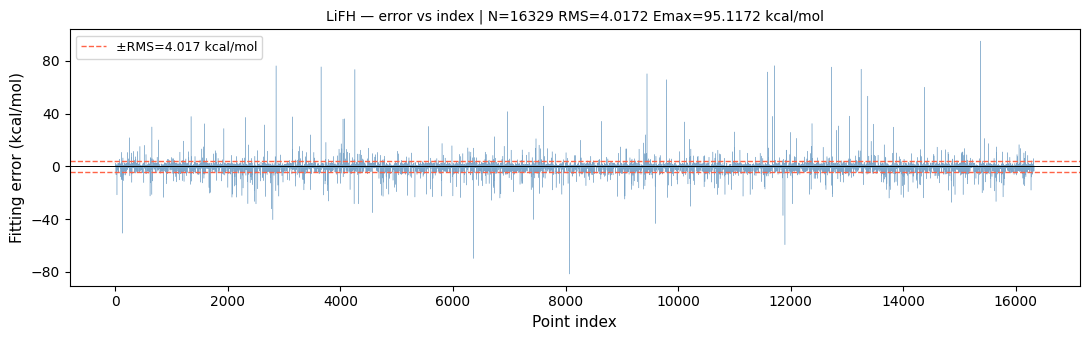

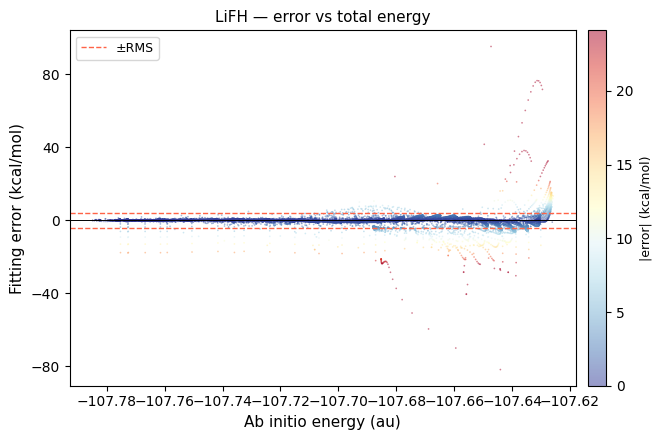

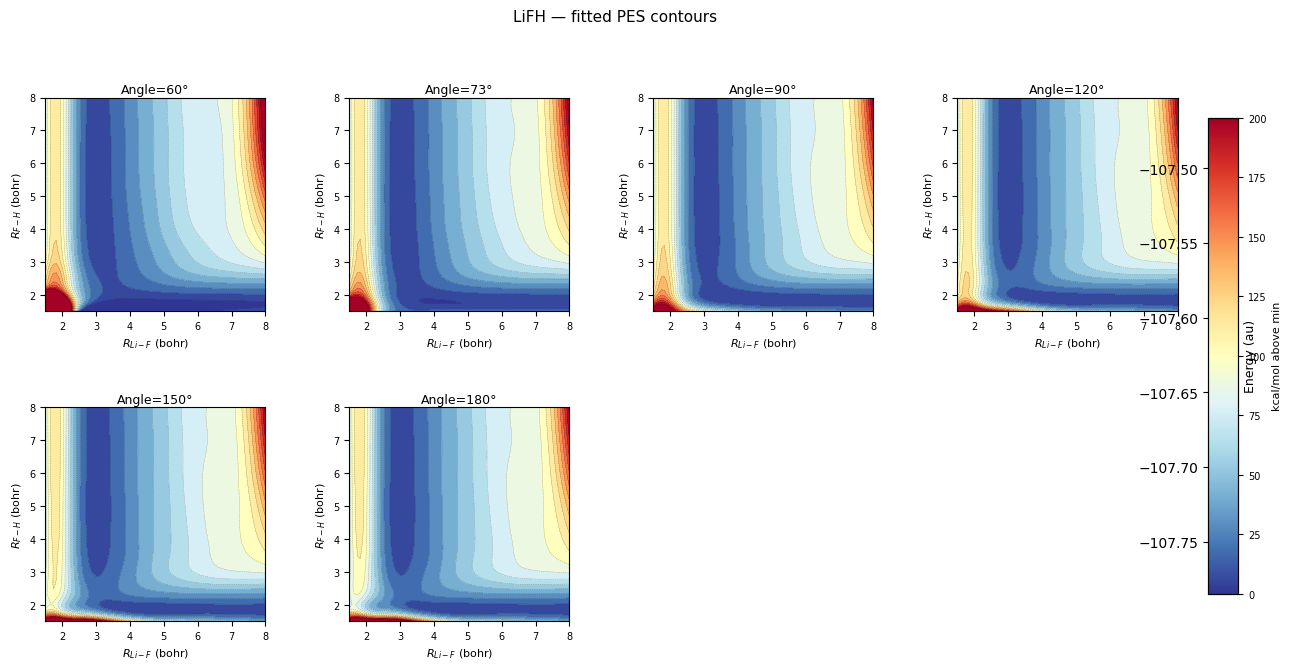

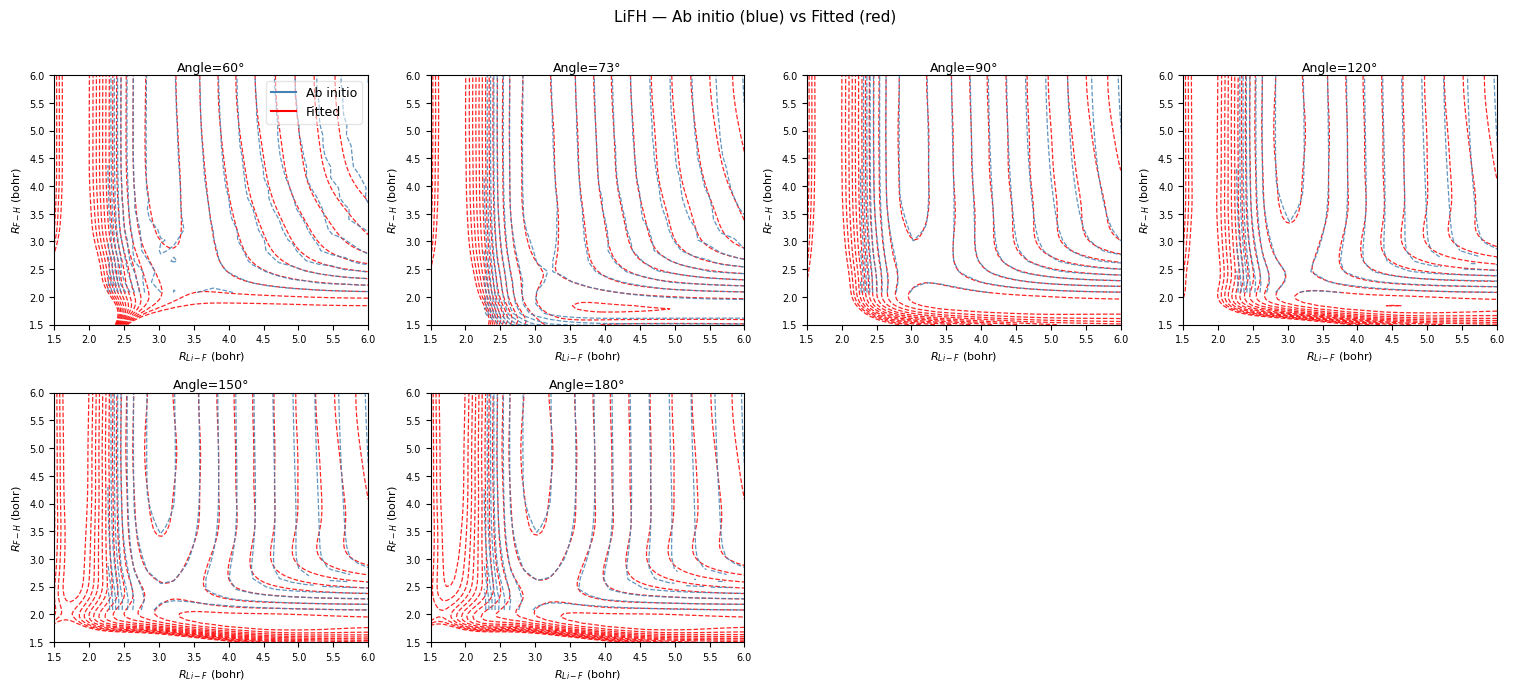

In [20]:
# =============================================================================
# Cell 14: RUN — change SYSTEM in Cell 4 to switch between systems
# =============================================================================
# Order recommended: H3 → FH2 → LiFH → NaH2

results = run_fit(SYSTEM, cfg)
plot_all(results, cfg, SYSTEM)

In [ ]:
# Run once to get optimized LiF CHIPR params:
R_lif, E_lif = load_diatomic(f'{BASE}/LiFH/lif.dat', e0=-107.09133080)

def optimize_chipr_lif(R, E, M=5, n_trials=30):
    from scipy.optimize import minimize
    ZA, ZB = 3, 9
    def rms_given_params(p):
        gama=np.abs(p[:M]); R_ref0=np.abs(p[M]); zeta=np.abs(p[M+1])
        params=dict(M=M,gama=gama,R_ref0=R_ref0,zeta=zeta,ZA=ZA,ZB=ZB)
        try:
            X=build_chipr_basis(R,params); c,_,_,_=np.linalg.lstsq(X,E,rcond=None)
            return np.sqrt(np.mean((X@c-E)**2))
        except: return 1e10
    best_rms=1e10; best_p=None
    rng=np.random.default_rng(42)
    for _ in range(n_trials):
        p0=np.concatenate([rng.uniform(0.1,3.0,M),
                           [rng.uniform(1.0,6.0), rng.uniform(0.2,1.5)]])
        res=minimize(rms_given_params,p0,method='Nelder-Mead',
                     options={'maxiter':10000,'xatol':1e-8,'fatol':1e-10})
        if res.fun<best_rms: best_rms=res.fun; best_p=res.x
    gama=np.abs(best_p[:M]); R_ref0=np.abs(best_p[M]); zeta=np.abs(best_p[M+1])
    print(f"LiF CHIPR M={M}: gama={np.round(gama,4)} R_ref0={R_ref0:.4f} zeta={zeta:.4f}")
    print(f"  RMS={best_rms:.6f} au = {best_rms*BFACT:.4f} kcal/mol")
    return dict(M=M,gama=list(gama),R_ref0=float(R_ref0),zeta=float(zeta),ZA=ZA,ZB=ZB)

best_chipr_LiF = optimize_chipr_lif(R_lif, E_lif, M=5)
print(f"\nPaste into cfg['chipr_AB']: {best_chipr_LiF}")

# Run this once to get optimized params, then paste into config:
R_nah, E_nah = load_diatomic(f'{BASE}/Nah2/nah_diat.dat', e0=-162.1766688)
best_chipr_AB = optimize_chipr_params(R_nah, E_nah, M=4)
print("\nPaste this into cfg['chipr_AB']:")
print(f"  chipr_AB = {best_chipr_AB}")

  Loaded 46 diatomic points from lif.dat
